## HF Assignment 2 – PageRank

In this notebook we:

- Implement a generic **PageRank iteration** function that also supports **personalized PageRank**.
- Run PageRank and personalized PageRank on the **Les Misérables** character co-appearance network used in Assignment 1.
- Handle special graph cases:
  - with and without edge weights,
  - directed vs. undirected graphs,
  - graphs with **0 outdegree (dangling) nodes**.
- Compare different parameters (e.g. damping factor \(\alpha\), personalization vectors).
- **Combine with Assignment 1** by showing **rank values on plots** (bar plots and graph visualizations).

In [6]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


def top_k(score_dict, k=5):
    """Return top-k items from a {node: score} dict, sorted by score descending.

    This mirrors the helper used in Assignment 1.
    """
    return sorted(score_dict.items(), key=lambda x: x[1], reverse=True)[:k]


def plot_rank_bar(rank_dict, k=10, title="Top nodes by rank"):
    """Bar plot of top-k ranked nodes (e.g. by PageRank)."""
    top = top_k(rank_dict, k=k)
    labels = [n for n, _ in top]
    values = [v for _, v in top]

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(labels)), values)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.ylabel("Rank value")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_graph_with_rank(G, rank_dict, title="Graph with rank values"):
    """Draw graph where node size and color encode rank values."""
    # Normalize ranks for plotting
    values = np.array([rank_dict[n] for n in G.nodes()])
    if values.max() > 0:
        sizes = 300 + 2000 * (values / values.max())
    else:
        sizes = 300

    pos = nx.kamada_kawai_layout(G)
    plt.figure(figsize=(10, 5))
    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_size=sizes,
        node_color=values,
        cmap="viridis",
    )
    nx.draw_networkx_edges(G, pos, alpha=0.4)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.colorbar(nodes, label="Rank value")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [7]:
def pagerank_iteration(
    G,
    alpha: float = 0.85,
    max_iter: int = 100,
    tol: float = 1e-6,
    personalization=None,
    weight: str | None = "weight",
    directed: bool | None = None,
    return_history: bool = False,
):
    """Iterative PageRank (with optional personalization).

    Parameters
    ----------
    G : networkx.Graph or DiGraph
        Input graph. Can be weighted/unweighted, directed/undirected.
    alpha : float
        Damping / teleportation parameter in [0, 1].
    max_iter : int
        Maximum number of power-iterations.
    tol : float
        Convergence tolerance on L1 difference between successive vectors.
    personalization : dict or array-like or None
        If None: uniform teleportation.
        If dict: {node: score} (will be normalized to a probability vector).
        If array-like: one value per node (in G.nodes() order), normalized.
    weight : str or None
        Edge attribute to use as weight. If None, all edges have weight 1.
    directed : bool or None
        If None, use "directed" if G is a DiGraph, otherwise symmetrize G.
    return_history : bool
        If True, also return list of intermediate rank vectors.

    Returns
    -------
    rank : dict
        {node: rank_value} mapping.
    history : list[np.ndarray] (optional)
        Rank vector at each iteration (including initial), if return_history.
    """
    # Decide orientation
    if directed is None:
        directed = isinstance(G, nx.DiGraph)

    H = G if directed else G.to_directed()

    nodes = list(H.nodes())
    n = len(nodes)
    if n == 0:
        return {}, [] if return_history else {}

    # Adjacency matrix (optionally weighted)
    A = nx.to_numpy_array(H, nodelist=nodes, weight=weight, dtype=float)

    # Handle dangling nodes: rows with zero outdegree
    row_sums = A.sum(axis=1, keepdims=True)
    dangling = (row_sums == 0).flatten()
    if np.any(dangling):
        # Distribute probability uniformly from dangling nodes
        A[dangling, :] = 1.0
        row_sums = A.sum(axis=1, keepdims=True)

    # Row-normalize to obtain transition matrix P (random walk)
    P = A / row_sums

    # Personalization / teleportation vector v
    if personalization is None:
        v = np.ones(n, dtype=float) / n
    elif isinstance(personalization, dict):
        v = np.array([personalization.get(node, 0.0) for node in nodes], dtype=float)
        s = v.sum()
        v = v / s if s > 0 else np.ones(n, dtype=float) / n
    else:
        v = np.asarray(personalization, dtype=float).reshape(-1)
        if v.shape[0] != n:
            raise ValueError("personalization length must match number of nodes")
        s = v.sum()
        v = v / s if s > 0 else np.ones(n, dtype=float) / n

    # Initial rank vector (uniform)
    p = np.ones(n, dtype=float) / n
    history = [p.copy()]

    for _ in range(max_iter):
        # Power iteration step: p_{k+1} = (1-alpha) * p_k P + alpha * v
        p_new = (1.0 - alpha) * (p @ P) + alpha * v

        if np.linalg.norm(p_new - p, ord=1) < tol:
            p = p_new
            history.append(p.copy())
            break

        p = p_new
        history.append(p.copy())

    rank = {node: float(score) for node, score in zip(nodes, p)}

    if return_history:
        return rank, history
    return rank

In [8]:
# Load the Les Misérables co-appearance network (same dataset as Assignment 1)
G_lesmis = nx.les_miserables_graph()

print(f"Nodes: {G_lesmis.number_of_nodes()}, edges: {G_lesmis.number_of_edges()}")

# Inspect whether the graph is weighted and directed
print(f"Directed: {G_lesmis.is_directed()}")
example_edge = next(iter(G_lesmis.edges(data=True)))
print("Example edge with attributes:", example_edge)

Nodes: 77, edges: 254
Directed: False
Example edge with attributes: ('Napoleon', 'Myriel', {'weight': 1})


Top 10 nodes by standard PageRank (weighted, undirected):
  Valjean              0.0328
  Myriel               0.0249
  Thenardier           0.0176
  Marius               0.0175
  Gavroche             0.0162
  Fantine              0.0159
  MlleGillenormand     0.0152
  Enjolras             0.0150
  Cosette              0.0149
  Courfeyrac           0.0147


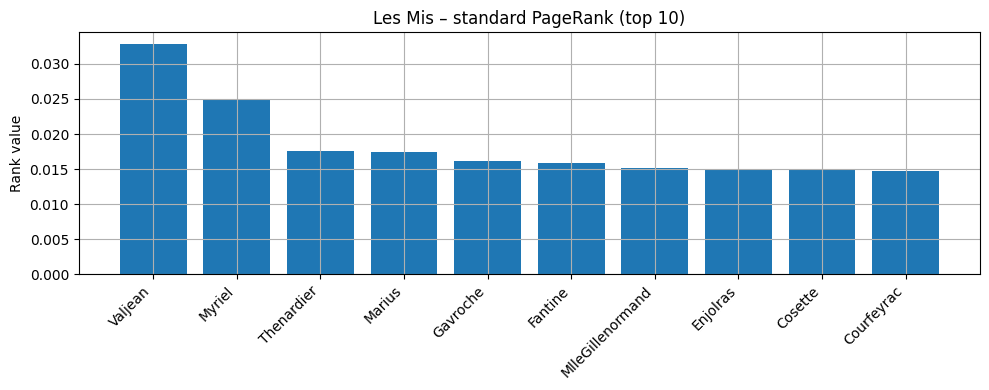

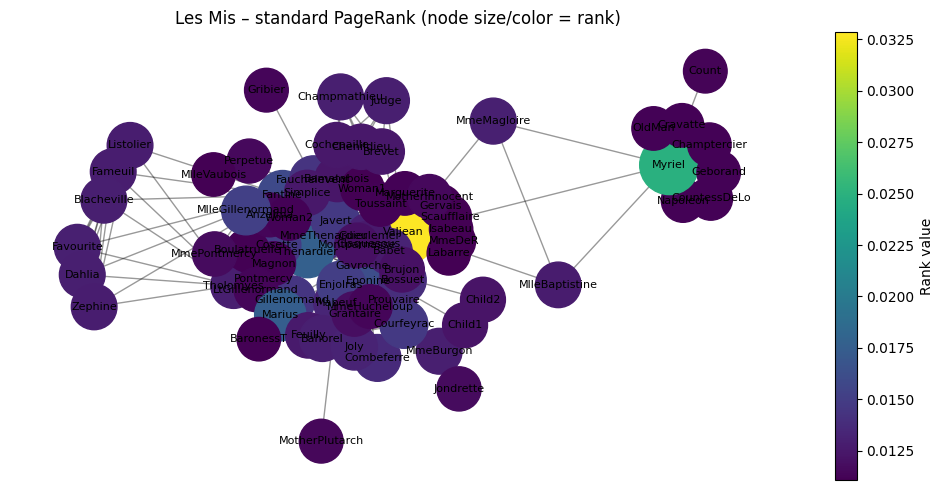

In [9]:
# 1) Standard PageRank on the weighted, undirected Les Mis graph

pr_lesmis = pagerank_iteration(G_lesmis, alpha=0.85, max_iter=200, tol=1e-8,
                               personalization=None, weight="weight", directed=False)

print("Top 10 nodes by standard PageRank (weighted, undirected):")
for name, score in top_k(pr_lesmis, k=10):
    print(f"  {name:20s} {score:.4f}")

plot_rank_bar(pr_lesmis, k=10, title="Les Mis – standard PageRank (top 10)")
plot_graph_with_rank(G_lesmis, pr_lesmis, title="Les Mis – standard PageRank (node size/color = rank)")

Top 10 nodes by personalized PageRank (towards Valjean):
  Valjean              0.8564
  Cosette              0.0261
  Marius               0.0170
  Javert               0.0146
  Thenardier           0.0106
  Fantine              0.0079
  Fauchelevent         0.0067
  MmeThenardier        0.0064
  Myriel               0.0045
  Enjolras             0.0038


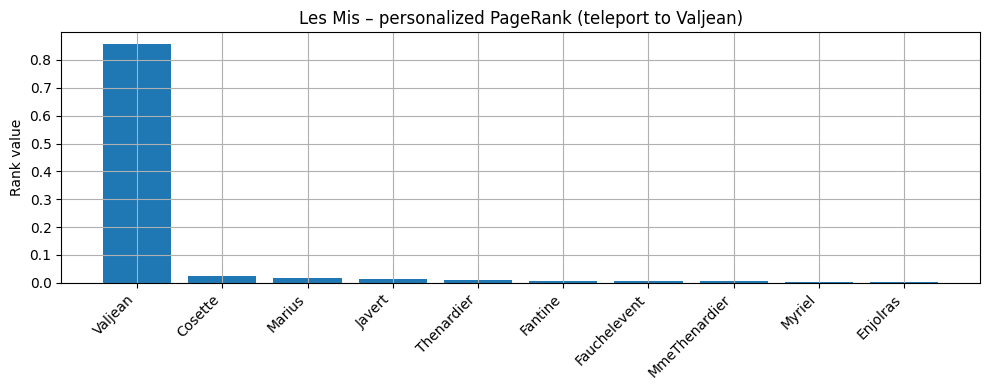

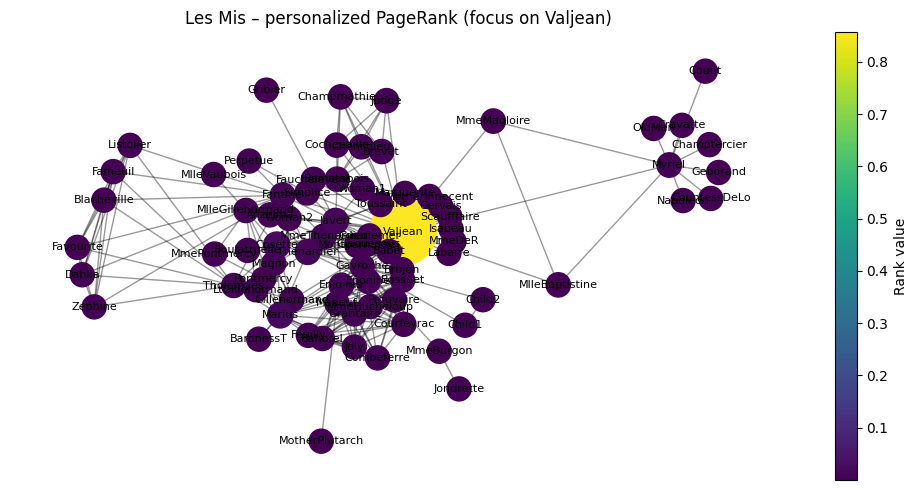


Top 10 nodes by personalized PageRank (multi-target):
Targets: ['Valjean', 'Javert', 'Marius']
  Valjean              0.3104
  Marius               0.2908
  Javert               0.2891
  Cosette              0.0193
  Enjolras             0.0101
  Thenardier           0.0096
  Fantine              0.0075
  Gillenormand         0.0060
  Courfeyrac           0.0044
  MmeThenardier        0.0036


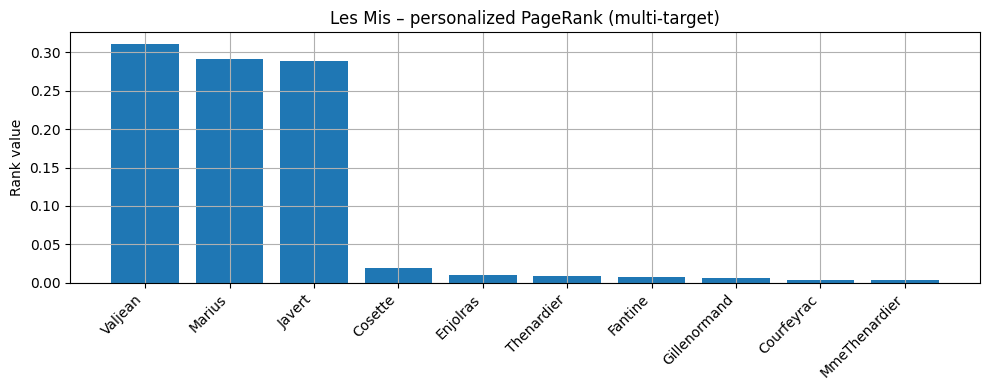

In [10]:
# 2) Personalized PageRank towards selected characters

# Personalize towards a single node (e.g., Valjean)
if "Valjean" in G_lesmis:
    pers_valjean = {n: (1.0 if n == "Valjean" else 0.0) for n in G_lesmis.nodes()}
    pr_valjean = pagerank_iteration(G_lesmis, alpha=0.85, max_iter=200, tol=1e-8,
                                    personalization=pers_valjean,
                                    weight="weight", directed=False)

    print("Top 10 nodes by personalized PageRank (towards Valjean):")
    for name, score in top_k(pr_valjean, k=10):
        print(f"  {name:20s} {score:.4f}")

    plot_rank_bar(pr_valjean, k=10,
                  title="Les Mis – personalized PageRank (teleport to Valjean)")
    plot_graph_with_rank(G_lesmis, pr_valjean,
                         title="Les Mis – personalized PageRank (focus on Valjean)")

# Personalize towards a small set of nodes (e.g., Valjean + Javert + Marius)
targets = [n for n in ["Valjean", "Javert", "Marius"] if n in G_lesmis]
if targets:
    pers_multi = {n: (1.0 if n in targets else 0.0) for n in G_lesmis.nodes()}
    pr_multi = pagerank_iteration(G_lesmis, alpha=0.85, max_iter=200, tol=1e-8,
                                  personalization=pers_multi,
                                  weight="weight", directed=False)

    print("\nTop 10 nodes by personalized PageRank (multi-target):")
    print("Targets:", targets)
    for name, score in top_k(pr_multi, k=10):
        print(f"  {name:20s} {score:.4f}")

    plot_rank_bar(pr_multi, k=10,
                  title="Les Mis – personalized PageRank (multi-target)")

In [11]:
# 3) Effect of parameters: compare different alpha values

alphas = [0.60, 0.85, 0.95]
results = {}

for a in alphas:
    results[a] = pagerank_iteration(G_lesmis, alpha=a, max_iter=200, tol=1e-8,
                                    personalization=None,
                                    weight="weight", directed=False)

# Show top-5 lists side by side
for a in alphas:
    print(f"\nTop 5 nodes by PageRank (alpha = {a}):")
    for name, score in top_k(results[a], k=5):
        print(f"  {name:20s} {score:.4f}")

# Simple comparison: Spearman correlation between different alpha settings
from scipy.stats import spearmanr

base = results[alphas[1]]  # use alpha=0.85 as reference
base_vec = np.array([base[n] for n in G_lesmis.nodes()])

for a in alphas:
    vec = np.array([results[a][n] for n in G_lesmis.nodes()])
    rho, _ = spearmanr(base_vec, vec)
    print(f"Spearman correlation PR(alpha={alphas[1]}) vs PR(alpha={a}): {rho:.4f}")


Top 5 nodes by PageRank (alpha = 0.6):
  Valjean              0.0617
  Myriel               0.0378
  Marius               0.0271
  Thenardier           0.0247
  Gavroche             0.0212

Top 5 nodes by PageRank (alpha = 0.85):
  Valjean              0.0328
  Myriel               0.0249
  Thenardier           0.0176
  Marius               0.0175
  Gavroche             0.0162

Top 5 nodes by PageRank (alpha = 0.95):
  Valjean              0.0198
  Myriel               0.0173
  Thenardier           0.0146
  Marius               0.0144
  Gavroche             0.0141
Spearman correlation PR(alpha=0.85) vs PR(alpha=0.6): 0.9919
Spearman correlation PR(alpha=0.85) vs PR(alpha=0.85): 1.0000
Spearman correlation PR(alpha=0.85) vs PR(alpha=0.95): 0.9946


Top 5 nodes – weighted vs. unweighted (undirected):
Weighted:
  Valjean              0.0328
  Myriel               0.0249
  Thenardier           0.0176
  Marius               0.0175
  Gavroche             0.0162

Unweighted:
  Valjean              0.0303
  Myriel               0.0244
  Gavroche             0.0172
  Thenardier           0.0162
  Javert               0.0161

Unweighted (directed, symmetrized):
  Valjean              0.0303
  Myriel               0.0244
  Gavroche             0.0172
  Thenardier           0.0162
  Javert               0.0161


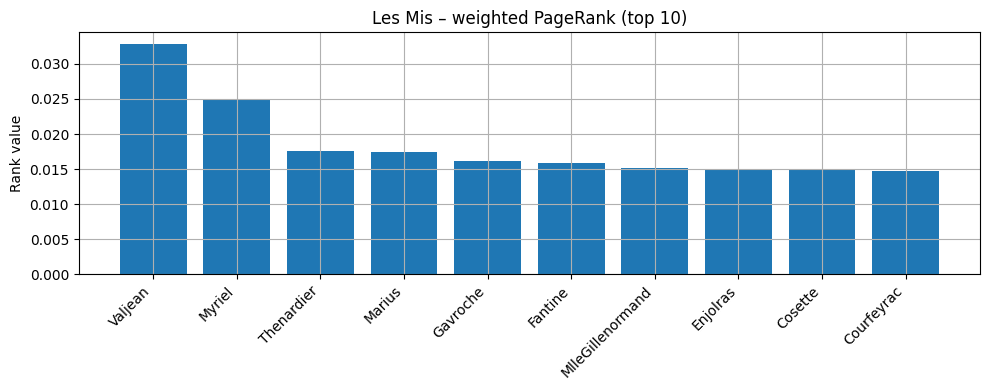

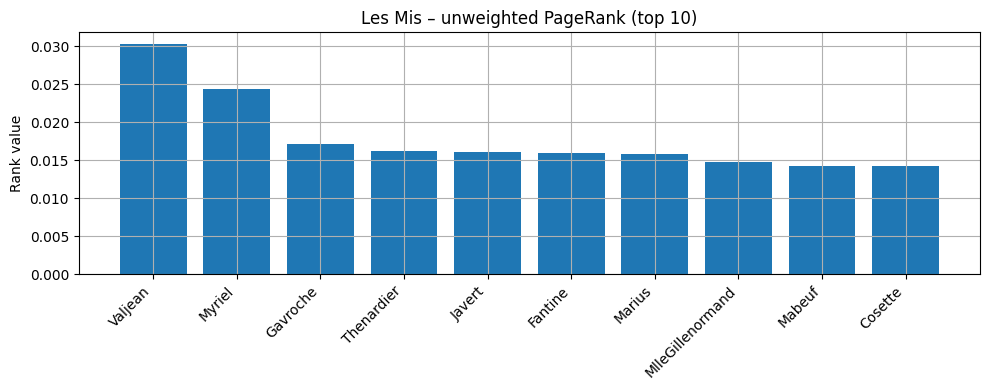

In [12]:
# 4) With and without edge weights; directed vs. undirected

# Unweighted version: ignore edge weights
G_unweighted = nx.Graph(G_lesmis)  # drops edge attributes
G_unweighted_directed = G_unweighted.to_directed()

pr_weighted = pagerank_iteration(G_lesmis, alpha=0.85, max_iter=200, tol=1e-8,
                                 personalization=None, weight="weight", directed=False)
pr_unweighted = pagerank_iteration(G_unweighted, alpha=0.85, max_iter=200, tol=1e-8,
                                   personalization=None, weight=None, directed=False)
pr_unweighted_dir = pagerank_iteration(G_unweighted_directed, alpha=0.85, max_iter=200, tol=1e-8,
                                       personalization=None, weight=None, directed=True)

print("Top 5 nodes – weighted vs. unweighted (undirected):")
print("Weighted:")
for name, score in top_k(pr_weighted, k=5):
    print(f"  {name:20s} {score:.4f}")

print("\nUnweighted:")
for name, score in top_k(pr_unweighted, k=5):
    print(f"  {name:20s} {score:.4f}")

print("\nUnweighted (directed, symmetrized):")
for name, score in top_k(pr_unweighted_dir, k=5):
    print(f"  {name:20s} {score:.4f}")

# Bar plots to visualize differences
plot_rank_bar(pr_weighted, k=10, title="Les Mis – weighted PageRank (top 10)")
plot_rank_bar(pr_unweighted, k=10, title="Les Mis – unweighted PageRank (top 10)")

Toy graph nodes: [0, 1, 2, 3]
Toy graph edges: [(0, 1), (0, 3), (1, 2), (2, 0)]

PageRank on toy graph with dangling node:
  0: 0.2602
  2: 0.2577
  1: 0.2411
  3: 0.2411


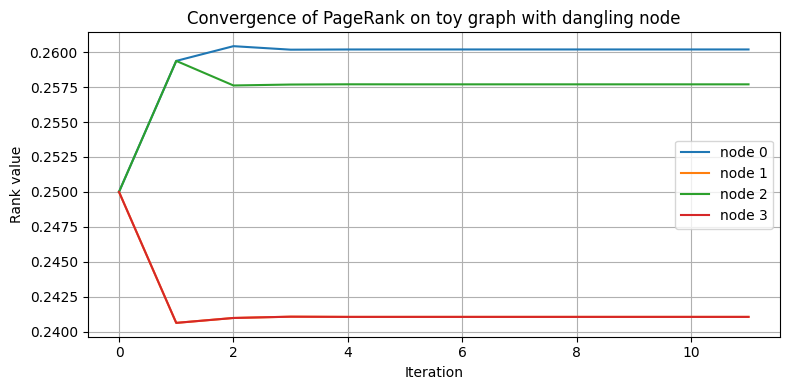

In [13]:
# 5) Handling dangling nodes (0 outdegree)

# Toy directed graph with a dangling node (node 3 has no outgoing edges)
G_toy = nx.DiGraph()
G_toy.add_edges_from([
    (0, 1),
    (1, 2),
    (2, 0),  # 0,1,2 form a cycle
    (0, 3),  # 3 is a sink / dangling node (no outgoing edges)
])

print("Toy graph nodes:", G_toy.nodes())
print("Toy graph edges:", list(G_toy.edges()))

pr_toy, history_toy = pagerank_iteration(G_toy, alpha=0.85, max_iter=100, tol=1e-10,
                                         personalization=None, weight=None,
                                         directed=True, return_history=True)

print("\nPageRank on toy graph with dangling node:")
for name, score in top_k(pr_toy, k=4):
    print(f"  {name}: {score:.4f}")

# Plot convergence of ranks over iterations (just for debugging / illustration)
P = np.array(history_toy)
plt.figure(figsize=(8, 4))
for i in range(P.shape[1]):
    plt.plot(range(P.shape[0]), P[:, i], label=f"node {i}")
plt.xlabel("Iteration")
plt.ylabel("Rank value")
plt.title("Convergence of PageRank on toy graph with dangling node")
plt.legend()
plt.tight_layout()
plt.show()